In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sys
sys.path.append('../')
from utils.data import Subject, load_participant_list
import copy

In [3]:
base_dir = '/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample'
sub_ids = load_participant_list(base_dir)

In [4]:
subjects24 = [Subject(base_dir, sub_id) for sub_id in sub_ids]

/Users/hugofluhr/phd_local/repositories/learning-habits-analysis/notebooks/../utils/data.py:211: UserWarning: Last 1 trial(s) of block had no response, filling with 0


In [5]:
subjects26 = copy.deepcopy(subjects24)

In [6]:
# load modeling data
modeling24_dir = 'modeling_data/2024-09-27'
modeling26_dir = 'modeling_data/2026-02-06'
for subject in subjects24:
    subject.add_modeling_data(modeling24_dir)
for subject in subjects26:
    subject.add_modeling_data(modeling26_dir)

In [7]:
# Exhaustive flagging and reporting for RL and CK modeling data changes
rl_cols = [f'stim{i}_value_rl' for i in range(1, 9)]
ck_cols = [f'stim{i}_value_ck' for i in range(1, 9)]
threshold_rl = 0.01  # RL change threshold
threshold_ck = 0.01  # CK change threshold
flagged_rl = []
flagged_ck = []
flagged_both = []
subject_diffs = []
for idx, (subj24, subj26) in enumerate(zip(subjects24, subjects26)):
    df24 = subj24.extended_trials[rl_cols + ck_cols].reset_index(drop=True)
    df25 = subj26.extended_trials[rl_cols + ck_cols].reset_index(drop=True)
    min_len = min(len(df24), len(df25))
    df24 = df24.iloc[:min_len]
    df25 = df25.iloc[:min_len]
    rl_diff = (df25[rl_cols] - df24[rl_cols]).abs()
    ck_diff = (df25[ck_cols] - df24[ck_cols]).abs()
    # Compute max, mean, and median difference for RL and CK values for this subject
    max_rl = rl_diff.max().max()
    mean_rl = rl_diff.mean().mean()
    median_rl = rl_diff.median().median()
    max_ck = ck_diff.max().max()
    mean_ck = ck_diff.mean().mean()
    median_ck = ck_diff.median().median()
    subject_diffs.append({
        'subject': subj24.sub_id,
        'max_rl_diff': max_rl,
        'mean_rl_diff': mean_rl,
        'median_rl_diff': median_rl,
        'max_ck_diff': max_ck,
        'mean_ck_diff': mean_ck,
        'median_ck_diff': median_ck
    })
    if max_rl > threshold_rl:
        flagged_rl.append(subj24.sub_id)
    if max_ck > threshold_ck:
        flagged_ck.append(subj24.sub_id)
    if (max_rl > threshold_rl) and (max_ck > threshold_ck):
        flagged_both.append(subj24.sub_id)
print('Flagged subjects for RL (max diff > threshold_rl):')
for sub_id in flagged_rl:
    print(sub_id)
print('\nFlagged subjects for CK (max diff > threshold_ck):')
for sub_id in flagged_ck:
    print(sub_id)
print('\nFlagged subjects for BOTH RL and CK:')
for sub_id in flagged_both:
    print(sub_id)
print('\nAll subject diffs summary:')
import pandas as pd
df_report = pd.DataFrame(subject_diffs)
print(df_report)
print('\nSubjects with any RL diff above threshold:')
print(df_report[df_report['max_rl_diff'] > threshold_rl]['subject'].tolist())
print('\nSubjects with any CK diff above threshold:')
print(df_report[df_report['max_ck_diff'] > threshold_ck]['subject'].tolist())

Flagged subjects for RL (max diff > threshold_rl):
sub-27
sub-50
sub-73

Flagged subjects for CK (max diff > threshold_ck):

Flagged subjects for BOTH RL and CK:

All subject diffs summary:
   subject   max_rl_diff  mean_rl_diff  median_rl_diff  max_ck_diff  \
0   sub-01  1.261421e-04  8.321375e-06    1.389209e-07     0.000109   
1   sub-02  0.000000e+00  0.000000e+00    0.000000e+00     0.000072   
2   sub-03  1.299518e-03  1.020937e-05    0.000000e+00     0.000126   
3   sub-04  2.052889e-07  4.894951e-10    0.000000e+00     0.000000   
4   sub-05  7.989509e-04  1.329490e-05    0.000000e+00     0.000067   
..     ...           ...           ...             ...          ...   
57  sub-69  4.402129e-04  5.350158e-06    4.884981e-15     0.000023   
58  sub-70  6.971687e-04  4.761610e-05    8.058187e-07     0.000007   
59  sub-71  1.124649e-04  8.816772e-07    0.000000e+00     0.000047   
60  sub-72  4.824211e-04  2.238531e-05    7.081050e-08     0.000151   
61  sub-73  2.209965e-02  3.4

In [8]:
df_report[df_report['subject']=='sub-73']

,subject,max_rl_diff,mean_rl_diff,median_rl_diff,max_ck_diff,mean_ck_diff,median_ck_diff
61,sub-73,0.0221,0.000345,0.0,0.000206,0.000065,0.000073


In [9]:
df_report[df_report['subject']=='sub-30']

,subject,max_rl_diff,mean_rl_diff,median_rl_diff,max_ck_diff,mean_ck_diff,median_ck_diff
26,sub-30,0.000592,0.000008,0.0,0.000118,0.000035,0.000034


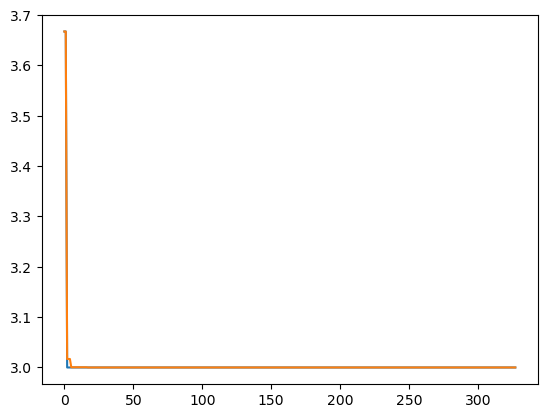

In [10]:
plt.plot(subjects24[40].extended_trials.stim4_value_rl)
plt.plot(subjects26[40].extended_trials.stim4_value_rl)

## Comparison with new modeling datasets (052026)

Reference: **2024-09-27** (`subjects24`). Three comparisons:
- 2024 vs **reduced** (RL_CK2, `Q5_Hpretest`)
- 2024 vs **combined** (RL_CK3/omega, `Q5_Hpretest`)
- **reduced** vs **combined**

In [11]:
# Load the two new modeling datasets (baseline = subjects26, i.e. 2026-02-06)
subjects_reduced  = [Subject(base_dir, sub_id) for sub_id in sub_ids]
subjects_combined = [Subject(base_dir, sub_id) for sub_id in sub_ids]

for s in subjects_reduced:
    s.add_modeling_data('modeling_data/2026-05-reduced')
for s in subjects_combined:
    s.add_modeling_data('modeling_data/2026-05-combined')

/Users/hugofluhr/phd_local/repositories/learning-habits-analysis/notebooks/../utils/data.py:211: UserWarning: Last 1 trial(s) of block had no response, filling with 0
/Users/hugofluhr/phd_local/repositories/learning-habits-analysis/notebooks/../utils/data.py:211: UserWarning: Last 1 trial(s) of block had no response, filling with 0


In [12]:
from scipy import stats

rl_cols = [f'stim{i}_value_rl' for i in range(1, 9)]
ck_cols = [f'stim{i}_value_ck' for i in range(1, 9)]

def per_subject_corr(subjects_ref, subjects_new, value_cols):
    """Pearson r per subject between reference and new model values, pooled across stim columns."""
    corrs, sub_ids_out = [], []
    for s_ref, s_new in zip(subjects_ref, subjects_new):
        ref = s_ref.extended_trials[value_cols].values.flatten()
        new = s_new.extended_trials[value_cols].values.flatten()
        mask = ~(np.isnan(ref) | np.isnan(new))
        r, _ = stats.pearsonr(ref[mask], new[mask])
        corrs.append(r)
        sub_ids_out.append(s_ref.sub_id)
    return pd.DataFrame({'sub_id': sub_ids_out, 'r': corrs})

corrs = {
    '2024 vs reduced  Q':  per_subject_corr(subjects24, subjects_reduced,  rl_cols),
    '2024 vs reduced  H':  per_subject_corr(subjects24, subjects_reduced,  ck_cols),
    '2024 vs combined Q':  per_subject_corr(subjects24, subjects_combined, rl_cols),
    '2024 vs combined H':  per_subject_corr(subjects24, subjects_combined, ck_cols),
    'reduced vs combined Q': per_subject_corr(subjects_reduced, subjects_combined, rl_cols),
    'reduced vs combined H': per_subject_corr(subjects_reduced, subjects_combined, ck_cols),
}

print("Median per-subject r:")
for label, df in corrs.items():
    print(f"  {label:<26}  median={df['r'].median():.4f}  min={df['r'].min():.4f}")

Median per-subject r:
  2024 vs reduced  Q          median=0.9994  min=0.9796
  2024 vs reduced  H          median=0.6100  min=0.1720
  2024 vs combined Q          median=0.9999  min=0.9917
  2024 vs combined H          median=0.5936  min=0.2807
  reduced vs combined Q       median=0.9999  min=0.9820
  reduced vs combined H       median=0.9156  min=0.0203


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_92632/3194281955.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(ref[mask], new[mask])
/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_92632/3194281955.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(ref[mask], new[mask])
/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_92632/3194281955.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(ref[mask], new[mask])
/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_92632/3194281955.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(ref[mask], new[mask])


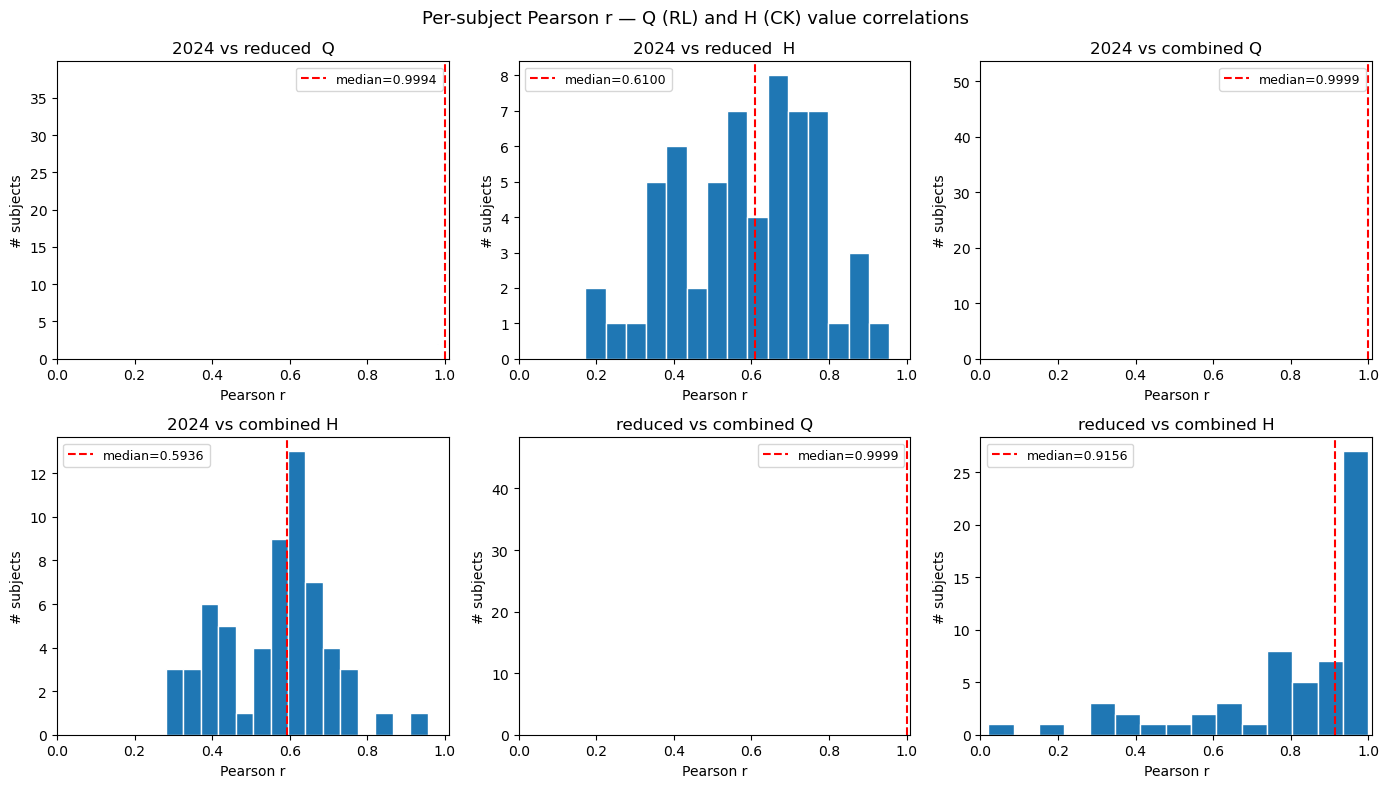

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Per-subject Pearson r — Q (RL) and H (CK) value correlations', fontsize=13)

labels = list(corrs.keys())
for ax, label in zip(axes.flat, labels):
    df = corrs[label]
    ax.hist(df['r'], bins=15, edgecolor='white')
    ax.axvline(df['r'].median(), color='red', linestyle='--', label=f"median={df['r'].median():.4f}")
    ax.set_title(label)
    ax.set_xlabel('Pearson r')
    ax.set_ylabel('# subjects')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1.01])

plt.tight_layout()
plt.show()

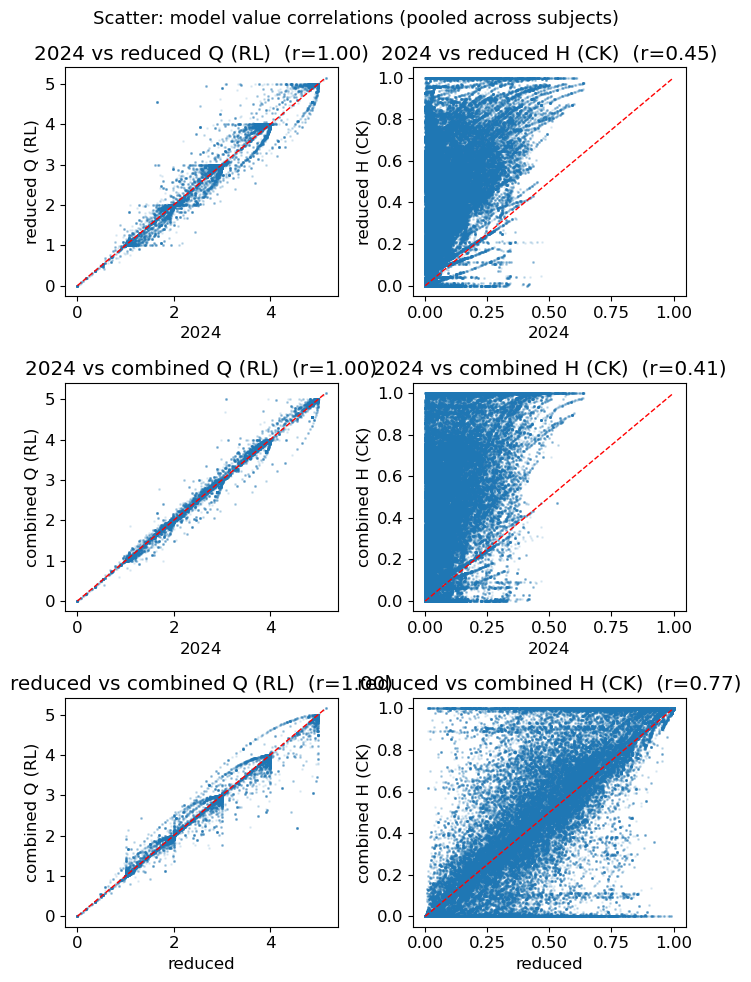

In [ ]:
comparisons_scatter = [
    (subjects24, subjects_reduced,  rl_cols, '2024 vs reduced Q (RL)'),
    (subjects24, subjects_reduced,  ck_cols, '2024 vs reduced H (CK)'),
    (subjects24, subjects_combined, rl_cols, '2024 vs combined Q (RL)'),
    (subjects24, subjects_combined, ck_cols, '2024 vs combined H (CK)'),
    (subjects_reduced, subjects_combined, rl_cols, 'reduced vs combined Q (RL)'),
    (subjects_reduced, subjects_combined, ck_cols, 'reduced vs combined H (CK)'),
]

fig, axes = plt.subplots(3, 2, figsize=(7, 10))
fig.suptitle('Scatter: model value correlations (pooled across subjects)', fontsize=13)

for ax, (s_ref_list, s_new_list, cols, label) in zip(axes.flat, comparisons_scatter):
    ref_all, new_all = [], []
    for s_ref, s_new in zip(s_ref_list, s_new_list):
        ref_all.append(s_ref.extended_trials[cols].values.flatten())
        new_all.append(s_new.extended_trials[cols].values.flatten())
    ref_all = np.concatenate(ref_all)
    new_all = np.concatenate(new_all)
    mask = ~(np.isnan(ref_all) | np.isnan(new_all))
    r, _ = stats.pearsonr(ref_all[mask], new_all[mask])
    ax.scatter(ref_all[mask], new_all[mask], s=1, alpha=0.1, rasterized=True)
    lims = [min(ref_all[mask].min(), new_all[mask].min()),
            max(ref_all[mask].max(), new_all[mask].max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(f'{label}  (r={r:.2f})')
    ref_label, new_label = label.split(' vs ')
    ax.set_xlabel(ref_label.strip())
    ax.set_ylabel(new_label.strip())

plt.tight_layout()
plt.show()

## Temporal evolution of Q- and H-values per stimulus

Mean ± SEM across subjects for each modeling dataset.

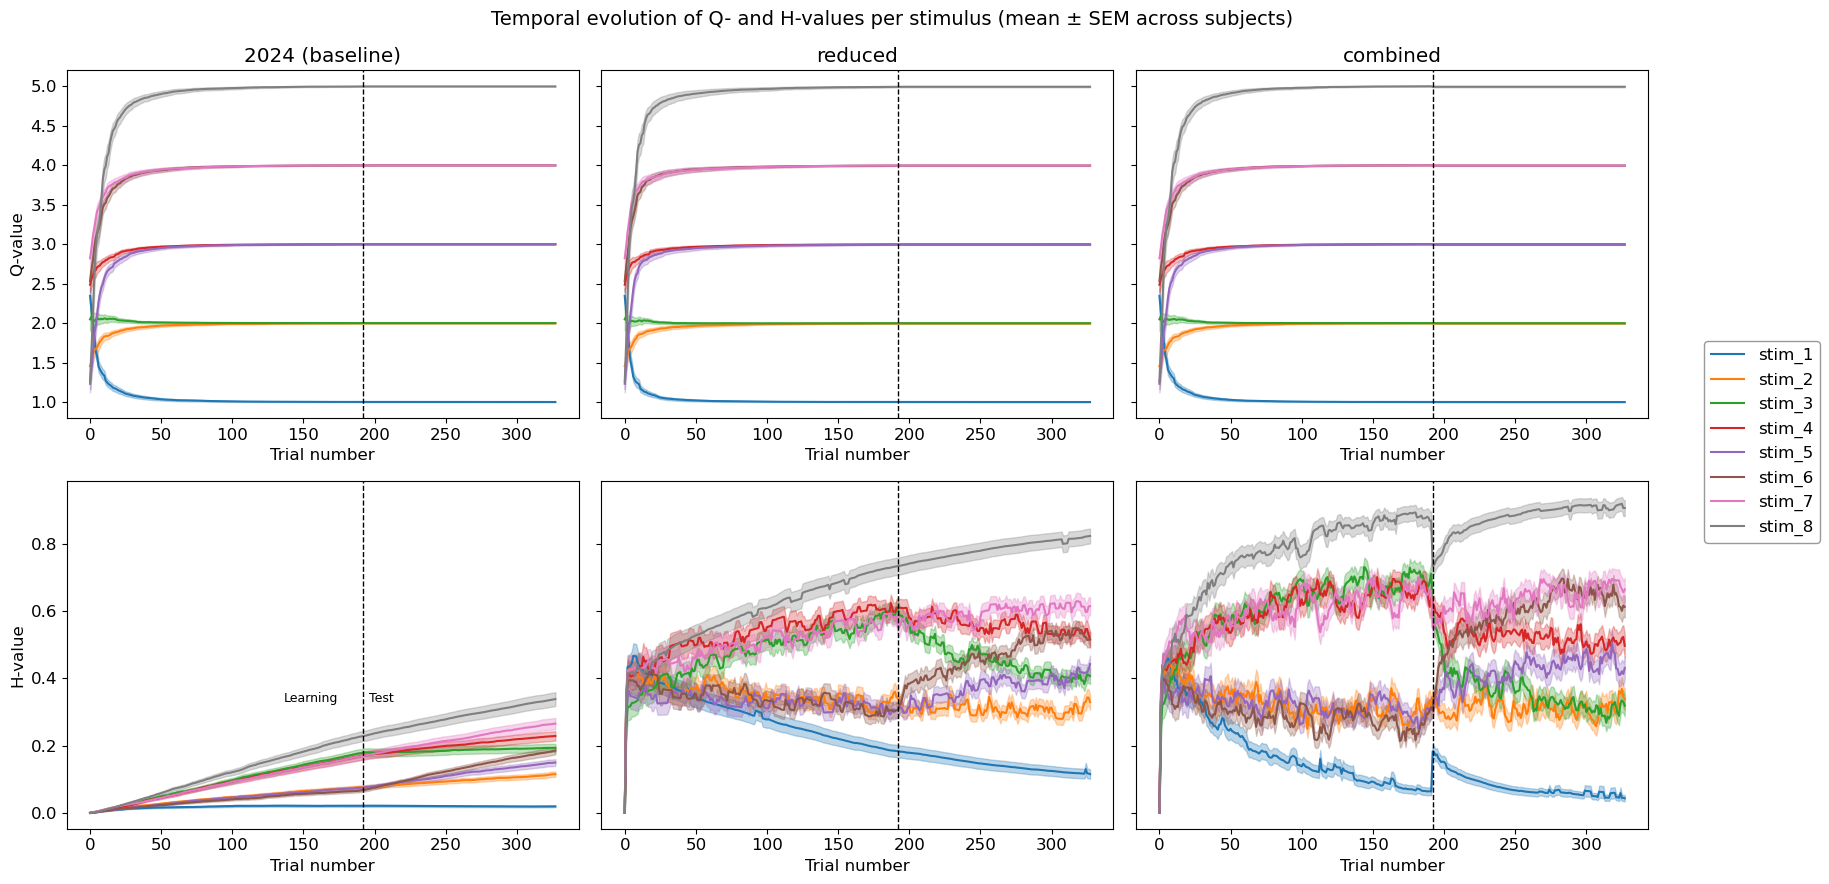

In [15]:
from itertools import cycle

rl_cols = [f'stim{i}_value_rl' for i in range(1, 9)]
ck_cols = [f'stim{i}_value_ck' for i in range(1, 9)]

dataset_labels = ['2024 (baseline)', 'reduced', 'combined']
dataset_subjects = [subjects24, subjects_reduced, subjects_combined]

def build_value_arrays(subjects_list, cols):
    n_trials = len(subjects_list[0].extended_trials)
    arr = np.zeros((len(subjects_list), n_trials, len(cols)))
    for i, sub in enumerate(subjects_list):
        arr[i] = sub.extended_trials[cols].values
    return arr

def plot_mean_sem_stimuli(data, axis=None, labels=None, alpha=0.3):
    if axis is None:
        axis = plt.gca()
    n_subjects, n_timepoints, n_stimuli = data.shape
    timepoints = np.arange(n_timepoints)
    color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    for i in range(n_stimuli):
        stim_data = data[:, :, i]
        mean = np.nanmean(stim_data, axis=0)
        sem = np.nanstd(stim_data, axis=0, ddof=1) / np.sqrt(n_subjects)
        color = next(color_cycle)
        label = labels[i] if labels else f'Stimulus {i+1}'
        axis.plot(timepoints, mean, color=color, label=label)
        axis.fill_between(timepoints, mean - sem, mean + sem, color=color, alpha=alpha)
    return axis

stim_labels = [f'stim_{i}' for i in range(1, 9)]
plt.rcParams.update({'font.size': 12})

fig, axs = plt.subplots(2, 3, figsize=(18, 9), sharey='row')
fig.suptitle('Temporal evolution of Q- and H-values per stimulus (mean ± SEM across subjects)', fontsize=14)

for col_idx, (ds_label, subjects_list) in enumerate(zip(dataset_labels, dataset_subjects)):
    RL_values = build_value_arrays(subjects_list, rl_cols)
    CK_values = build_value_arrays(subjects_list, ck_cols)

    # Q-values row
    ax_q = axs[0, col_idx]
    plot_mean_sem_stimuli(RL_values, axis=ax_q, labels=stim_labels)
    ax_q.axvline(x=192, color='black', linestyle='--', linewidth=1)
    ax_q.set_title(ds_label)
    ax_q.set_xlabel('Trial number')
    if col_idx == 0:
        ax_q.set_ylabel('Q-value')

    # H-values row
    ax_h = axs[1, col_idx]
    plot_mean_sem_stimuli(CK_values, axis=ax_h, labels=stim_labels)
    ax_h.axvline(x=192, color='black', linestyle='--', linewidth=1)
    ax_h.set_xlabel('Trial number')
    if col_idx == 0:
        ax_h.set_ylabel('H-value')
        ymax = ax_h.get_ylim()[1]
        ax_h.text(136, ymax * 0.95, 'Learning', fontsize=9, va='top')
        ax_h.text(196, ymax * 0.95, 'Test', fontsize=9, va='top')

# Shared legend from first subplot
handles, labels_leg = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='center right', bbox_to_anchor=(1.02, 0.5),
           frameon=True).get_frame().set_edgecolor('gray')

plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

In [43]:
subjects24[0].extended_trials.columns

Index(['block', 'left_stim', 'right_stim', 'left_value', 'right_value',
       'shift', 'action', 'rt', 'chosen_stim', 'reward', 'correct',
       't_first_stim', 't_second_stim', 't_action', 't_purple_frame',
       't_points_feedback', 't_iti_onset', 't_trial_end', 'first_stim',
       'second_stim', 'left_stim_name', 'right_stim_name', 'left_stim_cat',
       'right_stim_cat', 'first_stim_name', 'second_stim_name',
       'first_stim_cat', 'second_stim_cat', 'first_stim_value',
       'second_stim_value', 'first_stim_frequ', 'second_stim_frequ', 'phase',
       'run', 'trial2', 'stim_chosen', 'stim_unchosen', 'stim_rawID_chosen',
       'reward1', 'reward2', 'reward_chosen', 'reward_unchosen', 'diff_val',
       'flag_therapy1', 'flag_accuracy', 'flag_include', 'alpha_rl20',
       'beta_rl20', 'alpha_ck20', 'beta_ck20', 'choice_prob_left',
       'choice_prob_right', 'action_prob', 'stim1_value_rl', 'stim2_value_rl',
       'stim3_value_rl', 'stim4_value_rl', 'stim5_value_rl', 'sti

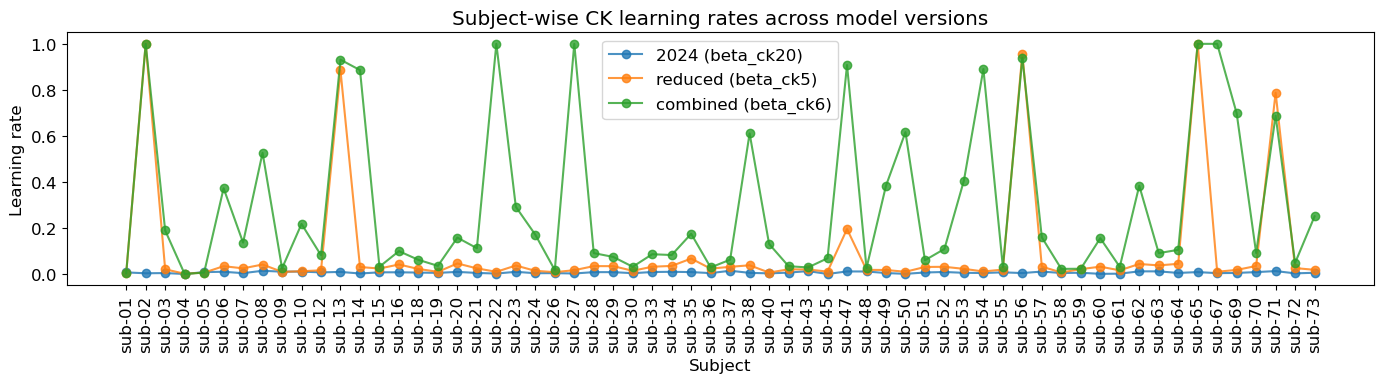

,sub_id,2024,reduced,combined
0,sub-01,0.006794,0.002666,0.002666
1,sub-02,0.003004,1.000000,1.000000
2,sub-03,0.003903,0.020311,0.189157
3,sub-04,0.000000,0.001051,0.000000
4,sub-05,0.008063,0.005898,0.005897


In [44]:
# Plot subject-wise CK learning-rate parameters across the 3 model lists
col_24 = 'alpha_ck20'
col_reduced = 'alpha_ck5'
col_combined = 'alpha_ck6'

def first_valid(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

rows = []
for s24, s_red, s_com in zip(subjects24, subjects_reduced, subjects_combined):
    rows.append({
        'sub_id': s24.sub_id,
        '2024': first_valid(s24.extended_trials[col_24]),
        'reduced': first_valid(s_red.extended_trials[col_reduced]),
        'combined': first_valid(s_com.extended_trials[col_combined]),
    })

lr_df = pd.DataFrame(rows)

plt.figure(figsize=(14, 4))
plt.plot(lr_df['sub_id'], lr_df['2024'], marker='o', linestyle='-', label='2024 (beta_ck20)', alpha=0.8)
plt.plot(lr_df['sub_id'], lr_df['reduced'], marker='o', linestyle='-', label='reduced (beta_ck5)', alpha=0.8)
plt.plot(lr_df['sub_id'], lr_df['combined'], marker='o', linestyle='-', label='combined (beta_ck6)', alpha=0.8)

plt.xticks(rotation=90)
plt.xlabel('Subject')
plt.ylabel('Learning rate')
plt.title('Subject-wise CK learning rates across model versions')
plt.legend()
plt.tight_layout()
plt.show()

lr_df.head()


In [46]:
lr_df.describe()

,2024,reduced,combined
count,62.000000,62.000000,62.000000
mean,0.006287,0.098857,0.289711
std,0.003542,0.249296,0.340223
min,0.000000,0.001051,0.000000
25%,0.003660,0.014346,0.038444
50%,0.005969,0.023422,0.110354
75%,0.008831,0.034904,0.400283
max,0.013945,1.000000,1.000000
